In [1]:
# ----------------------------
# Clean + aggregate Generic Keywords (GKs) by Basic Type
# Input : New_BT_GKs_Raw.csv (2 columns: "Basic Type", "Generic keywords")
# Output: New_BT_GKs_Cleaned_Unique.csv (2 columns: "Basic Type", "GKs")
#         where GKs is a Python-list-like string using single quotes:
#         ['kw1', 'kw2', ...]
# ----------------------------

import os
import re
import pandas as pd
from collections import OrderedDict

# ---------- 1) Locate input CSV (works in fresh notebooks) ----------
candidate_paths = [
    os.path.abspath("../Data/New_BT_GKs_Raw.csv"),        # relative to project root
    os.path.expanduser("~/Data/New_BT_GKs_Raw.csv"),   # user said home directory
    "/mnt/data/Data/New_BT_GKs_Raw.csv",               # common sandbox path
]

input_path = None
for p in candidate_paths:
    if os.path.exists(p):
        input_path = p
        break

if input_path is None:
    raise FileNotFoundError(
        "Couldn't find New_BT_GKs_Raw.csv. Tried:\n" + "\n".join(candidate_paths)
    )

print("✅ Reading:", input_path)

# ---------- 2) Read CSV robustly ----------
# (handles extra columns; we only keep the first two if needed)
df = pd.read_csv(input_path)

# Normalize column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# Try to find the required columns even if capitalization differs
def find_col(df_cols, target):
    target_norm = re.sub(r"\s+", " ", target.strip().lower())
    for c in df_cols:
        c_norm = re.sub(r"\s+", " ", c.strip().lower())
        if c_norm == target_norm:
            return c
    return None

bt_col = find_col(df.columns, "Basic Type")
gk_col = find_col(df.columns, "Generic keywords")

# If not found, fallback to first two columns
if bt_col is None or gk_col is None:
    if len(df.columns) < 2:
        raise ValueError("CSV must have at least 2 columns for Basic Type and Generic keywords.")
    bt_col, gk_col = df.columns[0], df.columns[1]
    print(f"⚠️ Column names not matched. Falling back to first two columns: {bt_col!r}, {gk_col!r}")
else:
    print(f"✅ Using columns: {bt_col!r}, {gk_col!r}")

df = df[[bt_col, gk_col]].copy()
df.rename(columns={bt_col: "Basic Type", gk_col: "Generic keywords"}, inplace=True)

# ---------- 3) Cleaning helpers ----------
def normalize_basic_type(x: str) -> str:
    if pd.isna(x):
        return ""
    # collapse whitespace + strip
    s = re.sub(r"\s+", " ", str(x)).strip()
    return s

def split_keywords(cell) -> list[str]:
    """
    Split a cell like:
      "Ceregrow, Baby Care, Baby Cereal, Nestle Ceregrow"
    into a list of cleaned keyword strings.
    """
    if pd.isna(cell):
        return []
    s = str(cell)

    # common cleanup: normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    # split on commas (simple + matches your sample)
    parts = [p.strip() for p in s.split(",")]

    # remove empties + normalize internal whitespace
    cleaned = []
    for p in parts:
        p2 = re.sub(r"\s+", " ", p).strip()
        if p2 != "":
            cleaned.append(p2)
    return cleaned

def ordered_unique_case_insensitive(items: list[str]) -> list[str]:
    """
    De-dup keywords case-insensitively while preserving first-seen order.
    Keeps the original casing of the first occurrence.
    """
    seen = set()
    out = []
    for it in items:
        key = it.casefold()
        if key not in seen:
            seen.add(key)
            out.append(it)
    return out

def to_single_quote_list_literal(items: list[str]) -> str:
    """
    Convert list -> string in format:
      ['a', 'b', 'c']
    Escapes single quotes inside items.
    """
    escaped = [i.replace("\\", "\\\\").replace("'", "\\'") for i in items]
    return "[" + ", ".join([f"'{i}'" for i in escaped]) + "]"

# ---------- 4) Clean + aggregate ----------
df["Basic Type"] = df["Basic Type"].map(normalize_basic_type)
df["Generic keywords"] = df["Generic keywords"].astype("string")

# Drop blank Basic Types
df = df[df["Basic Type"].ne("")].copy()

# Build aggregation with stable ordering:
# - preserve Basic Type order as first appearance in the file
# - preserve GK order as first appearance across that Basic Type
basic_type_order = df["Basic Type"].drop_duplicates().tolist()

gks_by_bt: dict[str, list[str]] = OrderedDict((bt, []) for bt in basic_type_order)

for bt, cell in zip(df["Basic Type"], df["Generic keywords"]):
    gks_by_bt[bt].extend(split_keywords(cell))

# De-dup per basic type
rows = []
for bt, gks in gks_by_bt.items():
    uniq_gks = ordered_unique_case_insensitive(gks)
    rows.append(
        {
            "Basic Type": bt,
            "GKs": to_single_quote_list_literal(uniq_gks),
            "_gk_count": len(uniq_gks),  # helper column for inspection (will drop before saving)
        }
    )

out_df = pd.DataFrame(rows)

# Optional: sort by Basic Type (comment out if you want original order)
# out_df = out_df.sort_values("Basic Type", kind="stable").reset_index(drop=True)

# ---------- 5) Save output ----------
input_dir = os.path.dirname(input_path) or "."
output_path = os.path.join(input_dir, "New_BT_GKs_Cleaned_Unique.csv")

out_df_to_save = out_df.drop(columns=["_gk_count"])
out_df_to_save.to_csv(output_path, index=False, encoding="utf-8")

print("✅ Saved:", output_path)

# ---------- 6) Quick sanity checks / preview ----------
print("\nPreview (first 20 rows):")
display(out_df_to_save.head(20))

print("\nTop 10 Basic Types by GK count:")
display(out_df.sort_values("_gk_count", ascending=False).head(10)[["Basic Type", "_gk_count"]])

✅ Reading: c:\Code\AI Tagging\Data\New_BT_GKs_Raw.csv
✅ Using columns: 'Basic Type', 'Generic keywords'
✅ Saved: c:\Code\AI Tagging\Data\New_BT_GKs_Cleaned_Unique.csv

Preview (first 20 rows):


,Basic Type,GKs
0,Staple Pins,"['Stationery', 'Staple Pins', 'Atlas Staple Pi..."
1,Isotonic Drink,"['100 Plus', 'Beverages', 'Groceries', 'Canned..."
2,Led Bulb,"['Light', 'Led Bulb', 'Dimo Bulb', 'Light Bulb..."
3,Nail Polish Remover,"['Cosmetics', 'Nail Polish Remover', '4rever N..."
4,Skin Care Gel,"['Aloe Gel', 'Aloe Vera Gel', 'Personal Care',..."
5,Body Lotion,"['Body Lotion', 'Personal Care', '4rever Body ..."
6,Body Wash,"['Body Wash', 'Personal Care', '4rever Body Wa..."
7,Cleansing Milk,"['Personal Care', 'Cleansing Milk', 'Cucumber ..."
8,Face Pack,"['Face Pack', 'Personal Care', '4rever Face Pa..."
9,Face Scrub,"['Face Scrub', 'Personal Care', '4rever Face S..."



Top 10 Basic Types by GK count:


,Basic Type,_gk_count
202,Biscuit,376
169,Chocolate,285
100,Ice Cream Tub,266
17,Shampoo,258
245,Soap,236
10,Face Wash,191
173,Pasta,152
366,Instant Coffee,138
5,Body Lotion,132
78,Tea Bags,131


In [1]:
import os
import pandas as pd
import numpy as np

# =========================
# CONFIG (edit these)
# =========================
N_SAMPLE = 50                 # total number of SKU rows you want in the test sample
RANDOM_SEED = 12               # reproducible randomness
MIN_PER_CATEGORY = 1           # ensure at least this many rows per category (if possible)
MAX_PER_CATEGORY = None        # optionally cap rows per category (e.g., 200). Keep None to disable.
CATEGORY_COL = "Categories"    # column name in Catalog_SKUs.csv
NAME_COL = "Name"              # column name in Catalog_SKUs.csv

# Input path: 'Testing Data/Catalog_SKUs.csv'
candidate_paths = [
    os.path.join("Testing Data", "Catalog_SKUs.csv"),
    os.path.expanduser("~/Testing Data/Catalog_SKUs.csv"),
    os.path.abspath(os.path.join("Testing Data", "Catalog_SKUs.csv")),
    "/mnt/data/Testing Data/Catalog_SKUs.csv",
    "/mnt/data/Testing_Data/Catalog_SKUs.csv",
]

input_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if input_path is None:
    raise FileNotFoundError(
        "Couldn't find Catalog_SKUs.csv. Tried:\n" + "\n".join(candidate_paths)
    )

print("✅ Reading:", input_path)

# =========================
# LOAD + CLEAN
# =========================
df = pd.read_csv(input_path)
df.columns = [c.strip() for c in df.columns]

if CATEGORY_COL not in df.columns or NAME_COL not in df.columns:
    raise ValueError(
        f"Expected columns '{NAME_COL}' and '{CATEGORY_COL}'. "
        f"Found: {list(df.columns)}"
    )

# Drop empty category/name rows
df = df.copy()
df[CATEGORY_COL] = df[CATEGORY_COL].astype("string").fillna("").str.strip()
df[NAME_COL] = df[NAME_COL].astype("string").fillna("").str.strip()
df = df[(df[CATEGORY_COL] != "") & (df[NAME_COL] != "")].reset_index(drop=True)

# If Categories contains multiple values separated by comma/pipe/etc.,
# normalize by taking the FIRST category as the sampling stratum.
# (Adjust split regex if your Categories column uses a different delimiter.)
df["_category_stratum"] = df[CATEGORY_COL].str.split(r"\s*[,|/]\s*", regex=True).str[0].str.strip()
df["_category_stratum"] = df["_category_stratum"].replace("", np.nan)
df = df.dropna(subset=["_category_stratum"]).reset_index(drop=True)

total_available = len(df)
if N_SAMPLE > total_available:
    print(f"⚠️ Requested N_SAMPLE={N_SAMPLE} but only {total_available} rows available. Using all rows.")
    N_SAMPLE = total_available

# =========================
# STRATIFIED SAMPLING LOGIC
# - Base: proportional to category sizes
# - Enforce MIN_PER_CATEGORY where possible
# - Optionally enforce MAX_PER_CATEGORY
# - Fill remainder by weighted sampling from remaining rows
# =========================
rng = np.random.default_rng(RANDOM_SEED)

cat_counts = df["_category_stratum"].value_counts()
cats = cat_counts.index.tolist()
k = len(cats)

# If N_SAMPLE is too small to satisfy MIN_PER_CATEGORY across all categories,
# reduce the effective min to fit.
effective_min = MIN_PER_CATEGORY
if k * effective_min > N_SAMPLE:
    effective_min = N_SAMPLE // k
    print(f"⚠️ N_SAMPLE too small for MIN_PER_CATEGORY={MIN_PER_CATEGORY} across {k} categories.")
    print(f"   Using effective MIN_PER_CATEGORY={effective_min}.")

# Initial allocation: proportional
proportions = cat_counts / cat_counts.sum()
alloc = (proportions * N_SAMPLE).round().astype(int)

# Enforce min where feasible
if effective_min > 0:
    alloc = alloc.clip(lower=effective_min)

# Enforce max if provided
if MAX_PER_CATEGORY is not None:
    alloc = alloc.clip(upper=int(MAX_PER_CATEGORY))

# Cap each category allocation to available rows in that category
alloc = pd.Series(
    {c: min(int(alloc.get(c, 0)), int(cat_counts[c])) for c in cats}
)

# Adjust total to exactly N_SAMPLE
current_total = int(alloc.sum())

def take_from_categories(alloc_series, needed):
    """Reduce allocation (if needed < 0) from categories with slack > 0."""
    if needed >= 0:
        return alloc_series

    needed = -needed
    # Reduce from categories that are above effective_min (or above 0 if effective_min is 0)
    floor = effective_min if effective_min > 0 else 0
    reducible = alloc_series - floor
    reducible = reducible[reducible > 0].sort_values(ascending=False)

    for c in reducible.index:
        if needed == 0:
            break
        dec = min(int(reducible[c]), needed)
        alloc_series[c] -= dec
        needed -= dec

    return alloc_series

def add_to_categories(alloc_series, needed):
    """Increase allocation up to availability (and MAX_PER_CATEGORY if set)."""
    if needed <= 0:
        return alloc_series

    # Remaining capacity per category
    cap = pd.Series({c: int(cat_counts[c]) for c in cats}) - alloc_series
    if MAX_PER_CATEGORY is not None:
        cap = np.minimum(cap, int(MAX_PER_CATEGORY) - alloc_series)
    cap = cap[cap > 0]

    # Distribute additions proportional to remaining capacity
    if cap.empty:
        return alloc_series

    cap_props = cap / cap.sum()
    add = (cap_props * needed).round().astype(int)

    # Ensure we don't add more than capacity
    for c in add.index:
        add[c] = min(int(add[c]), int(cap[c]))

    # Fix rounding mismatch by greedy filling
    added = int(add.sum())
    remainder = needed - added

    alloc_series.loc[add.index] += add

    if remainder > 0:
        cap2 = pd.Series({c: int(cat_counts[c]) for c in cats}) - alloc_series
        if MAX_PER_CATEGORY is not None:
            cap2 = np.minimum(cap2, int(MAX_PER_CATEGORY) - alloc_series)
        cap2 = cap2[cap2 > 0].sort_values(ascending=False)

        for c in cap2.index:
            if remainder == 0:
                break
            alloc_series[c] += 1
            remainder -= 1

    return alloc_series

# First pass: fix over/under allocation to match N_SAMPLE
alloc = take_from_categories(alloc.copy(), current_total - N_SAMPLE)
alloc = add_to_categories(alloc.copy(), N_SAMPLE - int(alloc.sum()))
final_total = int(alloc.sum())

# If still not exact (rare corner cases), fallback to simple global sample
if final_total != N_SAMPLE:
    print(f"⚠️ Allocation could not reach exact N_SAMPLE. Falling back to simple random sample of {N_SAMPLE}.")
    sampled_df = df.sample(n=N_SAMPLE, random_state=RANDOM_SEED).drop(columns=["_category_stratum"])
else:
    # Sample per category
    parts = []
    for c, n in alloc.items():
        if n <= 0:
            continue
        sub = df[df["_category_stratum"] == c]
        parts.append(sub.sample(n=n, random_state=int(rng.integers(0, 2**31 - 1))))
    sampled_df = pd.concat(parts, ignore_index=True)

    # Shuffle final sample
    sampled_df = sampled_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    sampled_df = sampled_df.drop(columns=["_category_stratum"])

# =========================
# SAVE OUTPUT FILES
# =========================
out_dir = os.path.dirname(input_path) or "."
sample_csv_path = os.path.join(out_dir, f"Catalog_SKUs_TestSample_{N_SAMPLE}.csv")
names_csv_path = os.path.join(out_dir, f"Catalog_SKUs_TestSample_{N_SAMPLE}_NamesOnly.csv")

sampled_df.to_csv(sample_csv_path, index=False, encoding="utf-8")

# Names-only file (one column: Name)
sampled_df[[NAME_COL]].to_csv(names_csv_path, index=False, encoding="utf-8")

print("✅ Saved sample file:", sample_csv_path)
print("✅ Saved names-only file:", names_csv_path)

# =========================
# QUICK DISTRIBUTION CHECK
# =========================
dist = sampled_df[CATEGORY_COL].astype("string").fillna("").str.split(r"\s*[,|/]\s*", regex=True).str[0].str.strip()
dist = dist.value_counts().rename_axis("Category").reset_index(name="count")

print("\nSample distribution (by first category token):")
display(dist.head(30))
print(f"\nTotal sampled rows: {len(sampled_df)}")

✅ Reading: Testing Data\Catalog_SKUs.csv
⚠️ Allocation could not reach exact N_SAMPLE. Falling back to simple random sample of 50.
✅ Saved sample file: Testing Data\Catalog_SKUs_TestSample_50.csv
✅ Saved names-only file: Testing Data\Catalog_SKUs_TestSample_50_NamesOnly.csv

Sample distribution (by first category token):


,Category,count
0,Groceries,26
1,Personal Care,9
2,Household,7
3,Dairy,2
4,Poultry and Meat,1
5,Frozen Foods,1
6,Baby Care,1
7,Pharmacy,1
8,Fresh Produce,1
9,Bakery,1



Total sampled rows: 50


# 🧪 Automated Multi-Approach SKU Tagging Benchmark

This section automates the **full tagging pipeline** (Category + Basic Type + Generic Keywords) using multiple approaches and models, then compares **accuracy vs. cost**.

### Approaches tested:
1. **Azure GPT "BT + Category"** — Sends all ~1.2k basic types to Azure GPT-4o in batches (current Streamlit method)
2. **Gemini "BT + Category"** — Same approach as #1 but using Google Gemini 2.0 Flash
3. **OpenRouter Models** — Tests the same prompts through various OpenRouter-hosted models

### How to add a new approach:
Register it with `register_approach(name, fn, description)` — see examples below.

In [9]:
# =============================================================================
# CELL 1: Configuration & Environment Setup
# =============================================================================
import os
import json
import time
import pickle
import hashlib
import requests
import numpy as np
import pandas as pd
from datetime import datetime
from dotenv import load_dotenv
from collections import OrderedDict
from dataclasses import dataclass, field, asdict
from typing import Callable, Optional

# Load environment variables (force reload to pick up changes)
load_dotenv(override=True)

# ---------- Azure OpenAI Config ----------
AZURE_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
AZURE_API_VERSION = os.getenv('AZURE_OPENAI_API_VERSION', '2024-02-01')
AZURE_ENDPOINT = os.getenv('AZURE_OPENAI_ENDPOINT')
AZURE_DEPLOYMENT = os.getenv('AZURE_OPENAI_DEPLOYMENT_NAME')
AZURE_EMBEDDING_DEPLOYMENT = os.getenv('AZURE_OPENAI_EMBEDDING_DEPLOYMENT', '')

# ---------- Google Gemini Config ----------
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY', '')
# GEMINI_MODEL = "gemini-2.0-flash"  # Default model - can also use gemini-1.5-flash, gemini-1.5-pro
GEMINI_MODEL = "gemini-3.5-flash"  # Default model - can also use gemini-1.5-flash, gemini-1.5-pro

# ---------- OpenRouter Config ----------
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY', '')
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

# Free models with large context windows (latency not a priority)
OPENROUTER_MODELS = [
    {"id": "openrouter/auto",                                "label": "OpenRouter Auto (Free)",      "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "google/gemma-3-27b-it:free",                     "label": "Gemma 3 27B (Free)",          "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "google/gemma-3-12b-it:free",                     "label": "Gemma 3 12B (Free)",          "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "meta-llama/llama-3.3-70b-instruct:free",         "label": "Llama 3.3 70B (Free)",        "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "qwen/qwen3-235b-a22b:free",                      "label": "Qwen 3 235B MoE (Free)",      "input_per_1k": 0.0, "output_per_1k": 0.0},
    {"id": "mistralai/mistral-small-3.1-24b-instruct",      "label": "Mistral Small 3.1 24B",       "input_per_1k": 0.03, "output_per_1k": 0.03},
    {"id": "deepseek/deepseek-chat-v3-0324",                  "label": "DeepSeek V3 0324",             "input_per_1k": 0.20, "output_per_1k": 0.20},
]

# ---------- Google Sheets (mapping data) ----------
SPREADSHEET_ID = "1-1DejLMWTf7YbUNKVa84fIiguL1XXb14wKJ-w28yOh4"
SHEET_IDS = {"BT_GK_mappings": "1433148032", "BT_CT_mappings": "1757740042"}

# ---------- Test Config ----------
TEST_SAMPLE_FILE = "Catalog_SKUs_TestSample_50.csv"   # ground-truth file with Name, Categories, Basic Type, Generic keywords
TESTING_DATA_DIR = os.path.join(os.getcwd(), "Testing Data")

# Results cache file — so completed approaches aren't re-run
RESULTS_CACHE_PATH = os.path.join(TESTING_DATA_DIR, "benchmark_results_cache.pkl")

# Batch sizes
CATEGORY_BATCH_SIZE = 30
BT_CATEGORY_BATCH_SIZE = 15
EMBEDDING_TOP_K = 30
EMBEDDING_BT_BATCH_SIZE = 15

print("✅ Config loaded")
print(f"   Azure endpoint: {AZURE_ENDPOINT}")
print(f"   Azure deployment: {AZURE_DEPLOYMENT}")
print(f"   Embedding deployment: {AZURE_EMBEDDING_DEPLOYMENT or '(not set)'}")
print(f"   Gemini API key: {'set' if GEMINI_API_KEY else 'NOT SET'}")
print(f"   Gemini model: {GEMINI_MODEL}")
print(f"   OpenRouter key: {'set' if OPENROUTER_API_KEY else 'NOT SET'}")
print(f"   OpenRouter models: {len(OPENROUTER_MODELS)}")
print(f"   Results cache: {RESULTS_CACHE_PATH}")
print(f"   Test sample: {TEST_SAMPLE_FILE}")
for m in OPENROUTER_MODELS:
    print(f"     - {m['label']} ({m['id']})")

✅ Config loaded
   Azure endpoint: https://oai-pickme-test-dev-sweedencentral-001.openai.azure.com/
   Azure deployment: aoi-pickme-4o-driverReg-dev-001
   Embedding deployment: text-embedding-ada-002
   Gemini API key: set
   Gemini model: gemini-3.5-flash
   OpenRouter key: set
   OpenRouter models: 7
   Results cache: c:\Code\AI Tagging\streamlit_app\Testing Data\benchmark_results_cache.pkl
   Test sample: Catalog_SKUs_TestSample_50.csv
     - OpenRouter Auto (Free) (openrouter/auto)
     - Gemma 3 27B (Free) (google/gemma-3-27b-it:free)
     - Gemma 3 12B (Free) (google/gemma-3-12b-it:free)
     - Llama 3.3 70B (Free) (meta-llama/llama-3.3-70b-instruct:free)
     - Qwen 3 235B MoE (Free) (qwen/qwen3-235b-a22b:free)
     - Mistral Small 3.1 24B (mistralai/mistral-small-3.1-24b-instruct)
     - DeepSeek V3 0324 (deepseek/deepseek-chat-v3-0324)


In [2]:
# =============================================================================
# CELL 2: Load Reference Data (Google Sheets mappings + test sample)
# =============================================================================

def load_google_sheet(spreadsheet_id, sheet_gid):
    """Load a Google Sheet as a pandas DataFrame."""
    url = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={sheet_gid}"
    return pd.read_csv(url)

def safe_parse_list(value):
    """Safely parse a string representation of a list."""
    if pd.isna(value) or value is None or not isinstance(value, str):
        return value
    if value.startswith('[') or value.startswith('{'):
        try:
            return json.loads(value.replace("'", '"'))
        except Exception:
            try:
                import ast
                return ast.literal_eval(value)
            except Exception:
                return value
    return value

# --- Load BT <-> Category mapping ---
print("Loading BT_CT_mappings...")
mapping_cat_bt_df = load_google_sheet(SPREADSHEET_ID, SHEET_IDS['BT_CT_mappings'])
for col in mapping_cat_bt_df.columns:
    if mapping_cat_bt_df[col].dtype == object:
        mapping_cat_bt_df[col] = mapping_cat_bt_df[col].apply(safe_parse_list)
print(f"  ✅ {len(mapping_cat_bt_df)} BT-CT records, columns: {list(mapping_cat_bt_df.columns)}")

# --- Load BT <-> GK mapping ---
print("Loading BT_GK_mappings...")
mapping_bt_gk_df = load_google_sheet(SPREADSHEET_ID, SHEET_IDS['BT_GK_mappings'])
for col in mapping_bt_gk_df.columns:
    if mapping_bt_gk_df[col].dtype == object:
        mapping_bt_gk_df[col] = mapping_bt_gk_df[col].apply(safe_parse_list)
print(f"  ✅ {len(mapping_bt_gk_df)} BT-GK records, columns: {list(mapping_bt_gk_df.columns)}")

# --- Derived lookups ---
all_basic_types = mapping_cat_bt_df.iloc[:, 0].unique().tolist()
category_list = mapping_cat_bt_df.iloc[:, 1].unique().tolist()

bt_to_category = {}
for _, row in mapping_cat_bt_df.iterrows():
    bt_to_category[row.iloc[0]] = row.iloc[1]

# Category -> [basic types]
category_to_bts = {}
for bt, cat in bt_to_category.items():
    category_to_bts.setdefault(cat, []).append(bt)

print(f"  ✅ {len(all_basic_types)} unique basic types across {len(category_list)} categories")

# --- Load ground-truth test sample ---
sample_path = os.path.join(TESTING_DATA_DIR, TEST_SAMPLE_FILE)
ground_truth_df = pd.read_csv(sample_path)
ground_truth_df.columns = [c.strip() for c in ground_truth_df.columns]
sku_names = ground_truth_df['Name'].tolist()

print(f"\n✅ Ground-truth sample loaded: {len(sku_names)} SKUs from {TEST_SAMPLE_FILE}")
display(ground_truth_df.head())

Loading BT_CT_mappings...
  ✅ 1605 BT-CT records, columns: ['Basic Tag Type', 'Category Tag Type']
Loading BT_GK_mappings...
  ✅ 1530 BT-GK records, columns: ['Basic Type', 'GKs']
  ✅ 1530 unique basic types across 15 categories

✅ Ground-truth sample loaded: 50 SKUs from Catalog_SKUs_TestSample_50.csv


,Name,Categories,Basic Type,Generic keywords
0,Kelloggs Corn Flakes 250g,Groceries,Corn Flakes,"Cereal, Groceries, Corn Flakes, Kelloggs Corn ..."
1,Md Original Green Chilli Sauce 400g,Groceries,Chilli Sauce,"Sauce, MD Sauce, Groceries, Chilli Sauce, Gree..."
2,Bonita Elegant Beauty Soap (Rose)-65g,Personal Care,Soap,"Soap, Rose Soap, Beauty Soap, Bonita Soap, Per..."
3,Pork Bacon Ends 300g,Poultry and Meat,Pork,"Pork, Bacon Ends, Pork Bacon, Pork Bacon Ends,..."
4,Finagle Garlic Prawn Chiken Pizza 310g,Frozen Foods,Pizza,"Pizza, Frozen Foods, Frozen Pizza, Chicken Piz..."


In [3]:
# =============================================================================
# CELL 3: Approach Registry & Shared Utilities
# =============================================================================
from openai import AzureOpenAI
from utils import (
    batch_basictype_category_prompt,
    batch_embedding_bt_category_prompt,
    generic_keyword_prompt,
    calculate_cost,
)
from embedding_utils import (
    build_bt_embeddings,
    get_sku_embeddings,
    find_similar_basic_types_batch,
)

# ---- Result data structures ----
@dataclass
class ApproachResult:
    """Stores results for one approach run."""
    approach_name: str
    description: str
    model_label: str
    # Per-SKU results: list of dicts with keys: sku_name, category, basic_type, generic_keywords
    predictions: list = field(default_factory=list)
    # Cost tracking
    total_tokens: int = 0
    prompt_tokens: int = 0
    completion_tokens: int = 0
    total_cost: float = 0.0
    embedding_cost: float = 0.0
    gpt_cost: float = 0.0
    elapsed_seconds: float = 0.0
    errors: list = field(default_factory=list)

# ---- Registry ----
APPROACH_REGISTRY: dict[str, dict] = OrderedDict()

def register_approach(name: str, fn: Callable, description: str = ""):
    """
    Register a tagging approach.

    `fn` signature: fn(sku_names: list[str]) -> ApproachResult
    It receives the list of SKU names and must return an ApproachResult.
    """
    APPROACH_REGISTRY[name] = {"fn": fn, "description": description}
    print(f"  📌 Registered approach: {name}")

# ---- Shared helper: call Azure OpenAI ----
def azure_gpt_call(prompt: str, deployment: str = None) -> tuple[str, dict]:
    """Call Azure OpenAI and return (response_text, usage_stats)."""
    client = AzureOpenAI(
        api_key=AZURE_API_KEY,
        api_version=AZURE_API_VERSION,
        azure_endpoint=AZURE_ENDPOINT,
    )
    dep = deployment or AZURE_DEPLOYMENT
    completion = client.chat.completions.create(
        model=dep,
        messages=[{"role": "system", "content": prompt}],
    )
    text = completion.choices[0].message.content
    usage = completion.usage
    cost = calculate_cost(usage.prompt_tokens, usage.completion_tokens, dep)
    stats = {
        "prompt_tokens": usage.prompt_tokens,
        "completion_tokens": usage.completion_tokens,
        "total_tokens": usage.total_tokens,
        **cost,
    }
    return text, stats

# ---- Rate-limit config for OpenRouter free tier ----
OPENROUTER_CALL_DELAY = 8        # seconds to wait between consecutive API calls (free tier ≈ 10 req/min)
OPENROUTER_MAX_RETRIES = 10      # generous retries for free-tier rate limits
OPENROUTER_INITIAL_BACKOFF = 8   # initial backoff in seconds (doubles each retry)
OPENROUTER_MODEL_COOLDOWN = 15   # seconds to wait before starting a new model (lets rate limits reset)
OPENROUTER_MAX_CONSECUTIVE_429 = 5  # bail out of a model after N consecutive 429 errors

# ---- Shared helper: call OpenRouter (with retries + rate-limit awareness) ----
_openrouter_last_call_time = 0.0  # tracks when we last called the API
_openrouter_consecutive_429 = 0   # tracks consecutive 429 errors for bail-out logic

def openrouter_call(prompt: str, model_id: str, input_per_1k: float, output_per_1k: float, max_retries: int = None) -> tuple[str, dict]:
    """Call an OpenRouter model with retry logic and rate-limit pacing. Returns (response_text, usage_stats)."""
    global _openrouter_last_call_time, _openrouter_consecutive_429

    if max_retries is None:
        max_retries = OPENROUTER_MAX_RETRIES

    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
        "HTTP-Referer": "https://sku-tagging-benchmark.local",
    }
    payload = {
        "model": model_id,
        "messages": [{"role": "system", "content": prompt}],
    }

    # Pace calls: wait at least OPENROUTER_CALL_DELAY seconds between requests
    elapsed_since_last = time.time() - _openrouter_last_call_time
    if elapsed_since_last < OPENROUTER_CALL_DELAY:
        wait_for = OPENROUTER_CALL_DELAY - elapsed_since_last
        time.sleep(wait_for)

    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            _openrouter_last_call_time = time.time()
            resp = requests.post(f"{OPENROUTER_BASE_URL}/chat/completions", headers=headers, json=payload, timeout=180)
            resp.raise_for_status()
            data = resp.json()

            # Check for OpenRouter-level errors
            if "error" in data:
                raise ValueError(f"OpenRouter error: {data['error']}")

            text = data["choices"][0]["message"]["content"]
            usage = data.get("usage", {})
            pt = usage.get("prompt_tokens", 0)
            ct = usage.get("completion_tokens", 0)
            stats = {
                "prompt_tokens": pt,
                "completion_tokens": ct,
                "total_tokens": pt + ct,
                "input_cost": (pt / 1000) * input_per_1k,
                "output_cost": (ct / 1000) * output_per_1k,
                "total_cost": (pt / 1000) * input_per_1k + (ct / 1000) * output_per_1k,
            }
            # Success — reset consecutive 429 counter
            _openrouter_consecutive_429 = 0
            return text, stats
        except Exception as e:
            last_error = e
            is_429 = "429" in str(e)
            if is_429:
                _openrouter_consecutive_429 += 1
                if _openrouter_consecutive_429 >= OPENROUTER_MAX_CONSECUTIVE_429:
                    print(f"    🚫 {OPENROUTER_MAX_CONSECUTIVE_429} consecutive 429s — skipping model {model_id}")
                    raise RuntimeError(f"Skipping {model_id}: hit {OPENROUTER_MAX_CONSECUTIVE_429} consecutive 429 rate limits") from e

            if attempt < max_retries:
                # Check for Retry-After header on 429 responses
                retry_after = None
                if hasattr(e, 'response') and e.response is not None:
                    retry_after = e.response.headers.get('Retry-After')
                elif 'resp' in dir() and hasattr(resp, 'headers'):
                    retry_after = resp.headers.get('Retry-After')

                if retry_after:
                    try:
                        wait = int(retry_after) + 1  # respect server's suggestion + 1s buffer
                    except (ValueError, TypeError):
                        wait = OPENROUTER_INITIAL_BACKOFF * (2 ** (attempt - 1))
                else:
                    wait = OPENROUTER_INITIAL_BACKOFF * (2 ** (attempt - 1))  # 8, 16, 32, 64, 120...

                # Cap wait at 120 seconds
                wait = min(wait, 120)
                print(f"    ⚠️ Retry {attempt}/{max_retries} for {model_id}: {e} (waiting {wait}s)")
                time.sleep(wait)
    raise last_error

# ---- Shared helper: clean JSON from LLM response ----
def clean_json_response(text: str) -> str:
    """Strip markdown fences and return clean JSON string."""
    text = text.strip()
    if text.startswith("```"):
        lines = text.split("\n")
        text = "\n".join(l for l in lines if not l.startswith("```"))
    return text.strip()

# ---- Shared helper: robustly parse BT+Cat batch response ----
def parse_bt_category_response(raw: str, batch_sku_names: list[str]) -> list[dict]:
    """
    Try to parse the BT+Category JSON response. Handles common LLM quirks:
    - Markdown fences
    - Missing 'results' wrapper
    - Array directly
    Returns list of dicts with keys: sku, basic_type, category
    """
    cleaned = clean_json_response(raw)
    try:
        parsed = json.loads(cleaned)
    except json.JSONDecodeError:
        # Try to extract anything JSON-like from the response
        import re
        json_match = re.search(r'[\[{].*[\]}]', cleaned, re.DOTALL)
        if json_match:
            try:
                parsed = json.loads(json_match.group())
            except json.JSONDecodeError:
                return []
        else:
            return []

    # Handle different response formats
    if isinstance(parsed, dict):
        if "results" in parsed:
            items = parsed["results"]
        else:
            # Single result wrapped in dict
            items = [parsed]
    elif isinstance(parsed, list):
        items = parsed
    else:
        return []

    # Normalize each item
    results = []
    for item in items:
        if not isinstance(item, dict):
            continue
        # Try common key variations
        sku = item.get("sku") or item.get("sku_name") or item.get("SKU") or item.get("name") or ""
        bt = item.get("basic_type") or item.get("Basic Type") or item.get("basicType") or ""
        cat = item.get("category") or item.get("Category") or ""
        if sku and bt:
            results.append({"sku": str(sku).strip(), "basic_type": str(bt).strip(), "category": str(cat).strip()})
    return results

# ---- Shared helper: robustly parse GK response ----
def parse_gk_response(raw: str) -> list[str]:
    """Parse the generic keywords response, handling common LLM quirks."""
    cleaned = clean_json_response(raw)
    try:
        parsed = json.loads(cleaned)
    except json.JSONDecodeError:
        import re
        json_match = re.search(r'[\[{].*[\]}]', cleaned, re.DOTALL)
        if json_match:
            try:
                parsed = json.loads(json_match.group())
            except json.JSONDecodeError:
                return []
        else:
            return []

    if isinstance(parsed, dict):
        # Try common key variations
        gks = (parsed.get("selected_generic_keywords")
               or parsed.get("generic_keywords")
               or parsed.get("Generic keywords")
               or parsed.get("keywords")
               or [])
        return gks if isinstance(gks, list) else []
    elif isinstance(parsed, list):
        return parsed
    return []

# ---- Shared helper: get GKs for an SKU given its BT + category ----
def get_gk_list_for_bt(basic_type: str) -> list:
    """Return the generic keyword list for a basic type from the mapping."""
    gk_col = mapping_bt_gk_df.columns[1]
    bt_col = mapping_bt_gk_df.columns[0]
    gk_rows = mapping_bt_gk_df.loc[mapping_bt_gk_df[bt_col] == basic_type, gk_col].tolist()
    if gk_rows and isinstance(gk_rows[0], list):
        return gk_rows[0]
    return gk_rows if gk_rows else []

print("✅ Registry & utilities ready (with improved rate-limit handling)")
print(f"   OpenRouter: {OPENROUTER_CALL_DELAY}s between calls, {OPENROUTER_MAX_RETRIES} retries, {OPENROUTER_INITIAL_BACKOFF}s initial backoff")
print(f"   Model cooldown: {OPENROUTER_MODEL_COOLDOWN}s between models, bail after {OPENROUTER_MAX_CONSECUTIVE_429} consecutive 429s")

✅ Registry & utilities ready (with improved rate-limit handling)
   OpenRouter: 8s between calls, 10 retries, 8s initial backoff
   Model cooldown: 15s between models, bail after 5 consecutive 429s


In [4]:
# =============================================================================
# CELL 4: Approach 1 — Azure GPT "BT + Category" (send all BTs to GPT)
# =============================================================================

def approach_azure_bt_category(sku_names: list[str]) -> ApproachResult:
    """
    Replicates the 'Find Basic Type and Category' button from the Streamlit app.
    Sends ALL basic types (grouped by category) to GPT and asks it to pick the best.
    Then fetches GKs via a second GPT call per SKU.
    """
    result = ApproachResult(
        approach_name="Azure GPT (All BTs)",
        description="Send all ~1.2k BTs grouped by category to GPT in batches",
        model_label=AZURE_DEPLOYMENT,
    )
    t0 = time.time()

    # --- Step 1: BT + Category assignment ---
    predictions = {name: {"sku_name": name, "category": "", "basic_type": "", "generic_keywords": []} for name in sku_names}

    for batch_start in range(0, len(sku_names), BT_CATEGORY_BATCH_SIZE):
        batch = sku_names[batch_start:batch_start + BT_CATEGORY_BATCH_SIZE]
        prompt = batch_basictype_category_prompt(batch, all_basic_types, bt_to_category)
        try:
            raw, stats = azure_gpt_call(prompt)
            result.prompt_tokens += stats["prompt_tokens"]
            result.completion_tokens += stats["completion_tokens"]
            result.total_tokens += stats["total_tokens"]
            result.gpt_cost += stats["total_cost"]

            parsed = json.loads(clean_json_response(raw))["results"]
            for item in parsed:
                name = item["sku"]
                if name in predictions:
                    predictions[name]["category"] = item.get("category", bt_to_category.get(item["basic_type"], ""))
                    predictions[name]["basic_type"] = item["basic_type"]
        except Exception as e:
            result.errors.append(f"BT+Cat batch {batch_start}: {e}")
            print(f"  ❌ BT+Cat batch error: {e}")

    # --- Step 2: Generic Keywords per SKU ---
    for name, pred in predictions.items():
        if not pred["basic_type"]:
            continue
        gk_list = get_gk_list_for_bt(pred["basic_type"])
        if not gk_list:
            continue
        prompt = generic_keyword_prompt(name, pred["category"], pred["basic_type"], gk_list)
        try:
            raw, stats = azure_gpt_call(prompt)
            result.prompt_tokens += stats["prompt_tokens"]
            result.completion_tokens += stats["completion_tokens"]
            result.total_tokens += stats["total_tokens"]
            result.gpt_cost += stats["total_cost"]

            parsed = json.loads(clean_json_response(raw))
            pred["generic_keywords"] = parsed.get("selected_generic_keywords", [])
        except Exception as e:
            result.errors.append(f"GK for {name}: {e}")

    result.total_cost = result.gpt_cost
    result.predictions = list(predictions.values())
    result.elapsed_seconds = time.time() - t0
    print(f"  ✅ {result.approach_name}: {len(result.predictions)} SKUs, ${result.total_cost:.6f}, {result.elapsed_seconds:.1f}s")
    return result

register_approach(
    "azure_gpt_all_bts",
    approach_azure_bt_category,
    "Azure GPT — sends all BTs grouped by category"
)

  📌 Registered approach: azure_gpt_all_bts


In [10]:
# =============================================================================
# CELL 5: Approach 2 — Google Gemini "BT + Category" (same as Azure approach)
# =============================================================================
# Uses the same prompt structure as Azure GPT, but calls Google Gemini instead.

from utils import gemini_call_with_usage

def gemini_call(prompt: str) -> tuple[str, dict]:
    """
    Wrapper around utils.gemini_call_with_usage for consistent interface.
    Returns (response_text, stats_dict) matching azure_gpt_call signature.
    """
    if not GEMINI_API_KEY:
        raise ValueError("GEMINI_API_KEY not set")
    
    response_text, usage_stats = gemini_call_with_usage(
        api_key=GEMINI_API_KEY,
        prompt=prompt,
        model_name=GEMINI_MODEL
    )
    
    # Convert to same format as azure_gpt_call stats
    stats = {
        "prompt_tokens": usage_stats.get("prompt_tokens", 0),
        "completion_tokens": usage_stats.get("completion_tokens", 0),
        "total_tokens": usage_stats.get("total_tokens", 0),
        "total_cost": usage_stats.get("total_cost", 0.0),
    }
    return response_text, stats


def approach_gemini_bt_category(sku_names: list[str]) -> ApproachResult:
    """
    Same approach as Azure GPT but using Google Gemini.
    Sends ALL basic types (grouped by category) to Gemini and asks it to pick the best.
    Then fetches GKs via a second Gemini call per SKU.
    """
    result = ApproachResult(
        approach_name="Gemini (All BTs)",
        description="Send all ~1.2k BTs grouped by category to Gemini in batches",
        model_label=GEMINI_MODEL,
    )
    t0 = time.time()

    if not GEMINI_API_KEY:
        result.errors.append("GEMINI_API_KEY not set")
        print("  ❌ GEMINI_API_KEY not set!")
        return result

    # --- Step 1: BT + Category assignment ---
    predictions = {name: {"sku_name": name, "category": "", "basic_type": "", "generic_keywords": []} for name in sku_names}

    for batch_start in range(0, len(sku_names), BT_CATEGORY_BATCH_SIZE):
        batch = sku_names[batch_start:batch_start + BT_CATEGORY_BATCH_SIZE]
        prompt = batch_basictype_category_prompt(batch, all_basic_types, bt_to_category)
        try:
            raw, stats = gemini_call(prompt)
            result.prompt_tokens += stats["prompt_tokens"]
            result.completion_tokens += stats["completion_tokens"]
            result.total_tokens += stats["total_tokens"]
            result.gpt_cost += stats["total_cost"]

            parsed_items = parse_bt_category_response(raw, batch)
            for item in parsed_items:
                name = item["sku"]
                if name in predictions:
                    predictions[name]["category"] = item.get("category", bt_to_category.get(item["basic_type"], ""))
                    predictions[name]["basic_type"] = item["basic_type"]
        except Exception as e:
            result.errors.append(f"BT+Cat batch {batch_start}: {e}")
            print(f"  ❌ BT+Cat batch error: {e}")

    # --- Step 2: Generic Keywords per SKU ---
    for name, pred in predictions.items():
        if not pred["basic_type"]:
            continue
        gk_list = get_gk_list_for_bt(pred["basic_type"])
        if not gk_list:
            continue
        prompt = generic_keyword_prompt(name, pred["category"], pred["basic_type"], gk_list)
        try:
            raw, stats = gemini_call(prompt)
            result.prompt_tokens += stats["prompt_tokens"]
            result.completion_tokens += stats["completion_tokens"]
            result.total_tokens += stats["total_tokens"]
            result.gpt_cost += stats["total_cost"]

            gks = parse_gk_response(raw)
            pred["generic_keywords"] = gks
        except Exception as e:
            result.errors.append(f"GK for {name}: {e}")

    result.total_cost = result.gpt_cost
    result.predictions = list(predictions.values())
    result.elapsed_seconds = time.time() - t0
    print(f"  ✅ {result.approach_name}: {len(result.predictions)} SKUs, ${result.total_cost:.6f}, {result.elapsed_seconds:.1f}s")
    return result

register_approach(
    "gemini_all_bts",
    approach_gemini_bt_category,
    "Google Gemini (same prompt as Azure, all BTs in batches)"
)

  📌 Registered approach: gemini_all_bts


In [21]:
# =============================================================================
# CELL 6: Approach 3 — OpenRouter models (dynamic registration)
# =============================================================================
# Registers one approach per model in OPENROUTER_MODELS.
# Each model becomes its own separate approach for side-by-side comparison.
# Uses retry logic + robust JSON parsing to minimize blank predictions.

def _make_openrouter_approach(model_cfg: dict):
    """Factory: returns an approach function bound to a specific OpenRouter model."""

    def approach_fn(sku_names: list[str]) -> ApproachResult:
        result = ApproachResult(
            approach_name=f"OR: {model_cfg['label']}",
            description=f"All BTs prompt via {model_cfg['id']}",
            model_label=model_cfg['id'],
        )
        t0 = time.time()

        if not OPENROUTER_API_KEY:
            result.errors.append("OPENROUTER_API_KEY not set — skipping")
            print(f"  ⏭️ Skipping {model_cfg['label']}: no API key")
            return result

        predictions = {name: {"sku_name": name, "category": "", "basic_type": "", "generic_keywords": []} for name in sku_names}

        # --- BT + Category (with retry + robust parsing) ---
        for batch_start in range(0, len(sku_names), BT_CATEGORY_BATCH_SIZE):
            batch = sku_names[batch_start:batch_start + BT_CATEGORY_BATCH_SIZE]
            prompt = batch_basictype_category_prompt(batch, all_basic_types, bt_to_category)
            try:
                raw, stats = openrouter_call(prompt, model_cfg["id"], model_cfg["input_per_1k"], model_cfg["output_per_1k"])
                result.prompt_tokens += stats["prompt_tokens"]
                result.completion_tokens += stats["completion_tokens"]
                result.total_tokens += stats["total_tokens"]
                result.gpt_cost += stats["total_cost"]

                parsed_items = parse_bt_category_response(raw, batch)
                matched_skus = set()
                for item in parsed_items:
                    name = item["sku"]
                    if name in predictions:
                        predictions[name]["category"] = item.get("category") or bt_to_category.get(item["basic_type"], "")
                        predictions[name]["basic_type"] = item["basic_type"]
                        matched_skus.add(name)

                # Log any SKUs in the batch that weren't in the response
                missing_from_response = [s for s in batch if s not in matched_skus]
                if missing_from_response:
                    result.errors.append(f"BT batch {batch_start}: {len(missing_from_response)} SKUs missing from response")
                    print(f"    ⚠️ Batch {batch_start}: {len(missing_from_response)}/{len(batch)} SKUs missing from model response")

            except Exception as e:
                result.errors.append(f"BT+Cat batch {batch_start}: {e}")
                print(f"  ❌ {model_cfg['label']} batch error: {e}")

        # Count how many SKUs got a BT assigned
        bt_assigned = sum(1 for p in predictions.values() if p["basic_type"])
        print(f"    📊 BT assigned: {bt_assigned}/{len(sku_names)} SKUs")

        # --- Generic Keywords (also via OpenRouter, with retry + robust parsing) ---
        gk_assigned = 0
        for name, pred in predictions.items():
            if not pred["basic_type"]:
                continue
            gk_list = get_gk_list_for_bt(pred["basic_type"])
            if not gk_list:
                continue
            prompt = generic_keyword_prompt(name, pred["category"], pred["basic_type"], gk_list)
            try:
                raw, stats = openrouter_call(prompt, model_cfg["id"], model_cfg["input_per_1k"], model_cfg["output_per_1k"])
                result.prompt_tokens += stats["prompt_tokens"]
                result.completion_tokens += stats["completion_tokens"]
                result.total_tokens += stats["total_tokens"]
                result.gpt_cost += stats["total_cost"]

                gks = parse_gk_response(raw)
                if gks:
                    pred["generic_keywords"] = gks
                    gk_assigned += 1
                else:
                    result.errors.append(f"GK empty response for {name}")
            except Exception as e:
                result.errors.append(f"GK for {name}: {e}")

        print(f"    📊 GKs assigned: {gk_assigned}/{bt_assigned} SKUs (that had BT)")

        result.total_cost = result.gpt_cost
        result.predictions = list(predictions.values())
        result.elapsed_seconds = time.time() - t0
        blank_count = sum(1 for p in result.predictions if not p["basic_type"])
        print(f"  ✅ {result.approach_name}: {len(result.predictions)} SKUs, {blank_count} blank, ${result.total_cost:.6f}, {result.elapsed_seconds:.1f}s")
        return result

    return approach_fn


# Dynamically register one approach per OpenRouter model
for _mcfg in OPENROUTER_MODELS:
    _key = f"openrouter_{_mcfg['id'].replace('/', '_')}"
    register_approach(_key, _make_openrouter_approach(_mcfg), f"OpenRouter: {_mcfg['label']}")

  📌 Registered approach: openrouter_openrouter_auto
  📌 Registered approach: openrouter_google_gemma-3-27b-it:free
  📌 Registered approach: openrouter_google_gemma-3-12b-it:free
  📌 Registered approach: openrouter_meta-llama_llama-3.3-70b-instruct:free
  📌 Registered approach: openrouter_qwen_qwen3-235b-a22b:free
  📌 Registered approach: openrouter_mistralai_mistral-small-3.1-24b-instruct
  📌 Registered approach: openrouter_deepseek_deepseek-chat-v3-0324


In [12]:
# =============================================================================
# CELL 7: Run Selected (or All) Approaches — with result caching
# =============================================================================
# Set APPROACHES_TO_RUN to a list of keys, or None to run ALL registered approaches.
# Example: APPROACHES_TO_RUN = ["azure_gpt_all_bts", "embedding_plus_gpt"]
# Set FORCE_RERUN to a list of keys to force re-run even if cached.

APPROACHES_TO_RUN = [
    # "azure_gpt_all_bts",
    "gemini_all_bts",
]

# Force rerun to get fresh results for comparison
FORCE_RERUN = [
    "azure_gpt_all_bts",
    "gemini_all_bts",
]

# --- Load cached results ---
def _load_results_cache() -> dict[str, ApproachResult]:
    if os.path.exists(RESULTS_CACHE_PATH):
        try:
            with open(RESULTS_CACHE_PATH, 'rb') as f:
                cached = pickle.load(f)
            print(f"📦 Loaded {len(cached)} cached results from {RESULTS_CACHE_PATH}")
            return cached
        except Exception as e:
            print(f"⚠️ Failed to load cache: {e}")
    return {}

def _save_results_cache(results: dict[str, ApproachResult]):
    os.makedirs(os.path.dirname(RESULTS_CACHE_PATH), exist_ok=True)
    with open(RESULTS_CACHE_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f"💾 Saved {len(results)} results to cache")

# --- Run ---
approaches_to_run = APPROACHES_TO_RUN or list(APPROACH_REGISTRY.keys())
all_results: dict[str, ApproachResult] = _load_results_cache()

# Show what's cached vs. needs running
cached_keys = [k for k in approaches_to_run if k in all_results and k not in FORCE_RERUN and all_results[k].predictions]
new_keys = [k for k in approaches_to_run if k not in cached_keys]

print(f"\n{len(approaches_to_run)} approaches selected, {len(cached_keys)} cached, {len(new_keys)} to run:\n")
for key in approaches_to_run:
    status = "✅ cached" if key in cached_keys else "🔄 will run"
    desc = APPROACH_REGISTRY.get(key, {}).get('description', '')
    print(f"  {status} — {key}: {desc}")

# Only run approaches that aren't cached
for idx, key in enumerate(new_keys):
    if key not in APPROACH_REGISTRY:
        print(f"\n⚠️ Approach '{key}' not registered — skipping")
        continue
    info = APPROACH_REGISTRY[key]

    # Cooldown between OpenRouter models to let rate limits reset
    is_openrouter = key.startswith("openrouter_")
    if is_openrouter and idx > 0:
        print(f"\n⏳ Cooling down {OPENROUTER_MODEL_COOLDOWN}s before next model...")
        time.sleep(OPENROUTER_MODEL_COOLDOWN)

    # Reset consecutive 429 counter for each new model
    global _openrouter_consecutive_429
    _openrouter_consecutive_429 = 0

    print(f"\n{'='*60}")
    print(f"▶ Running: {key}")
    print(f"{'='*60}")
    try:
        ar = info["fn"](sku_names)
        all_results[key] = ar
        # Save after each approach so no work is lost
        _save_results_cache(all_results)
    except Exception as e:
        print(f"  ❌ FATAL: {e}")
        all_results[key] = ApproachResult(
            approach_name=key, description=info["description"],
            model_label="error", errors=[str(e)]
        )
        _save_results_cache(all_results)

print(f"\n✅ All {len(all_results)} approaches complete (cached + new).")

📦 Loaded 12 cached results from c:\Code\AI Tagging\streamlit_app\Testing Data\benchmark_results_cache.pkl

1 approaches selected, 0 cached, 1 to run:

  🔄 will run — gemini_all_bts: Google Gemini (same prompt as Azure, all BTs in batches)

▶ Running: gemini_all_bts

GEMINI CALL REQUEST
Model: gemini-3.5-flash
Prompt (first 500 chars):

            You are an expert in food product classification for a large e-commerce food delivery platform.

            Your task is to analyze the given list of food SKU names and select the most appropriate basic type 
            for EACH SKU from the provided basic type list, organized by category.
            
            ### INSTRUCTIONS
            1. Process each SKU independently.
            2. For each SKU, carefully read the name to understand the product's food type, brand, ingred...

GEMINI CALL RESPONSE
Response: {
    "results": [
        {
            "sku": "Kelloggs Corn Flakes 250g",
            "basic_type": "Corn Flakes",
         

In [14]:
# =============================================================================
# CELL 8: Accuracy Evaluation (compare each approach to ground truth)
# =============================================================================

def evaluate_accuracy(result: ApproachResult, truth_df: pd.DataFrame) -> dict:
    """
    Compare an approach's predictions against the ground-truth DataFrame.
    Tracks blank/no-prediction SKUs separately from wrong predictions.

    Returns a dict with:
      - category_accuracy, basic_type_accuracy, avg_gk_recall (0-100 %)
      - blank_count: SKUs where model returned no BT prediction
      - per_sku: list of per-SKU detail dicts
    """
    pred_lookup = {p["sku_name"]: p for p in result.predictions}
    per_sku = []
    cat_correct = bt_correct = 0
    gk_accs = []
    blank_count = 0

    for _, row in truth_df.iterrows():
        name = row["Name"]
        expected_cat = str(row["Categories"]).strip()
        expected_bt = str(row["Basic Type"]).strip()
        expected_gks_raw = str(row.get("Generic keywords", ""))
        expected_gks = set(
            kw.strip() for kw in expected_gks_raw.strip("[]").replace("'", "").split(",") if kw.strip()
        )

        pred = pred_lookup.get(name, {})
        pred_cat = str(pred.get("category", "")).strip()
        pred_bt = str(pred.get("basic_type", "")).strip()
        pred_gks_raw = pred.get("generic_keywords", [])
        if isinstance(pred_gks_raw, str):
            pred_gks_raw = [kw.strip() for kw in pred_gks_raw.strip("[]").replace("'", "").split(",")]
        pred_gks = set(kw.strip() for kw in pred_gks_raw if kw.strip() if isinstance(kw, str))

        # Detect blank prediction
        is_blank = (pred_bt == "" or pred_bt == "None")

        if is_blank:
            blank_count += 1

        # Category match (case-insensitive)
        cat_match = pred_cat.lower() == expected_cat.lower() if not is_blank else False
        bt_match = pred_bt.lower() == expected_bt.lower() if not is_blank else False
        if cat_match:
            cat_correct += 1
        if bt_match:
            bt_correct += 1

        # GK accuracy
        if expected_gks:
            intersection = expected_gks & pred_gks
            gk_acc = (len(intersection) / len(expected_gks)) * 100
        else:
            gk_acc = 100.0 if not pred_gks else 0.0
        gk_accs.append(gk_acc)

        # Determine status label
        if is_blank:
            cat_status = "⬜ BLANK"
            bt_status = "⬜ BLANK"
        else:
            cat_status = "✅ PASS" if cat_match else "❌ FAIL"
            bt_status = "✅ PASS" if bt_match else "❌ FAIL"

        per_sku.append({
            "SKU": name,
            "Cat Status": cat_status,
            "BT Status": bt_status,
            "Expected Cat": expected_cat,
            "Predicted Cat": pred_cat,
            "Expected BT": expected_bt,
            "Predicted BT": pred_bt,
            "GK Recall (%)": round(gk_acc, 1),
            "Missing GKs": list(expected_gks - pred_gks),
            "Extra GKs": list(pred_gks - expected_gks),
        })

    n = len(truth_df)
    n_with_pred = n - blank_count
    return {
        "category_accuracy": round((cat_correct / n) * 100, 2) if n else 0,
        "basic_type_accuracy": round((bt_correct / n) * 100, 2) if n else 0,
        "avg_gk_recall": round(np.mean(gk_accs), 2) if gk_accs else 0,
        # Accuracy excluding blank predictions (how good is it when it does predict?)
        "cat_acc_excl_blank": round((cat_correct / n_with_pred) * 100, 2) if n_with_pred else 0,
        "bt_acc_excl_blank": round((bt_correct / n_with_pred) * 100, 2) if n_with_pred else 0,
        "blank_count": blank_count,
        "blank_pct": round((blank_count / n) * 100, 1) if n else 0,
        "per_sku": per_sku,
    }


# --- Run evaluation for all completed approaches ---
evaluation_results: dict[str, dict] = {}

for key, ar in all_results.items():
    if ar.errors and not ar.predictions:
        print(f"⏭️ Skipping {key}: no predictions (errors: {ar.errors})")
        continue
    ev = evaluate_accuracy(ar, ground_truth_df)
    evaluation_results[key] = ev
    print(f"📊 {ar.approach_name}:")
    print(f"   Cat: {ev['category_accuracy']}%  |  BT: {ev['basic_type_accuracy']}%  |  GK Recall: {ev['avg_gk_recall']}%")
    if ev['blank_count'] > 0:
        print(f"   ⬜ Blanks: {ev['blank_count']}/{len(ground_truth_df)} ({ev['blank_pct']}%)  |  BT excl blanks: {ev['bt_acc_excl_blank']}%")

print(f"\n✅ Evaluated {len(evaluation_results)} approaches")

📊 Azure GPT (All BTs):
   Cat: 86.0%  |  BT: 80.0%  |  GK Recall: 74.68%
📊 Embedding + GPT:
   Cat: 0.0%  |  BT: 0.0%  |  GK Recall: 0.0%
   ⬜ Blanks: 50/50 (100.0%)  |  BT excl blanks: 0%
📊 OpenRouter: OpenRouter Free (Auto):
   Cat: 0.0%  |  BT: 0.0%  |  GK Recall: 0.0%
   ⬜ Blanks: 50/50 (100.0%)  |  BT excl blanks: 0%
📊 OR: Gemma 3 27B (Free):
   Cat: 0.0%  |  BT: 0.0%  |  GK Recall: 0.0%
   ⬜ Blanks: 50/50 (100.0%)  |  BT excl blanks: 0%
📊 OR: Gemma 3 12B (Free):
   Cat: 0.0%  |  BT: 0.0%  |  GK Recall: 0.0%
   ⬜ Blanks: 50/50 (100.0%)  |  BT excl blanks: 0%
📊 OR: Llama 3.3 70B (Free):
   Cat: 0.0%  |  BT: 0.0%  |  GK Recall: 0.0%
   ⬜ Blanks: 50/50 (100.0%)  |  BT excl blanks: 0%
📊 OR: Qwen 3 235B MoE (Free):
   Cat: 0.0%  |  BT: 0.0%  |  GK Recall: 0.0%
   ⬜ Blanks: 50/50 (100.0%)  |  BT excl blanks: 0%
📊 OR: Mistral Small 3.1 24B (Free):
   Cat: 0.0%  |  BT: 0.0%  |  GK Recall: 0.0%
   ⬜ Blanks: 50/50 (100.0%)  |  BT excl blanks: 0%
📊 OR: DeepSeek V3 (Free):
   Cat: 0.0%  |  BT

In [15]:
# =============================================================================
# CELL 9: Comparison Dashboard — Accuracy vs. Cost
# =============================================================================

# --- Build summary table ---
summary_rows = []
for key in all_results:
    ar = all_results[key]
    ev = evaluation_results.get(key, {})
    summary_rows.append({
        "Approach": ar.approach_name,
        "Model": ar.model_label,
        "Cat Acc (%)": ev.get("category_accuracy", "-"),
        "BT Acc (%)": ev.get("basic_type_accuracy", "-"),
        "GK Recall (%)": ev.get("avg_gk_recall", "-"),
        "Blanks": ev.get("blank_count", 0),
        "Blank %": ev.get("blank_pct", 0),
        "BT excl Blank (%)": ev.get("bt_acc_excl_blank", "-"),
        "Embedding $": round(ar.embedding_cost, 6),
        "GPT $": round(ar.gpt_cost, 6),
        "Total $": round(ar.total_cost, 6),
        "Tokens": ar.total_tokens,
        "Time (s)": round(ar.elapsed_seconds, 1),
        "Errors": len(ar.errors),
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 80)
print("ACCURACY vs COST COMPARISON  (all approaches side-by-side)")
print("=" * 80)
display(summary_df)

# --- Save summary to CSV ---
summary_path = os.path.join(TESTING_DATA_DIR, "benchmark_summary.csv")
summary_df.to_csv(summary_path, index=False, encoding="utf-8")
print(f"\n✅ Summary saved to {summary_path}")

ACCURACY vs COST COMPARISON  (all approaches side-by-side)


,Approach,Model,Cat Acc (%),BT Acc (%),GK Recall (%),Blanks,Blank %,BT excl Blank (%),Embedding $,GPT $,Total $,Tokens,Time (s),Errors
0,Azure GPT (All BTs),aoi-pickme-4o-driverReg-dev-001,86.0,80.0,74.68,0,0.0,80.0,0.0,0.415195,0.415195,73371,278.9,0
1,Embedding + GPT,OR:openai/text-embedding-3-small + aoi-pickme-...,0.0,0.0,0.00,50,100.0,0.0,0.0,0.261220,0.261220,45142,121.3,0
2,OpenRouter: OpenRouter Free (Auto),openrouter/auto,0.0,0.0,0.00,50,100.0,0.0,0.0,0.000000,0.000000,50756,80.8,1
3,OR: Gemma 3 27B (Free),google/gemma-3-27b-it:free,0.0,0.0,0.00,50,100.0,0.0,0.0,0.000000,0.000000,0,150.9,4
4,OR: Gemma 3 12B (Free),google/gemma-3-12b-it:free,0.0,0.0,0.00,50,100.0,0.0,0.0,0.000000,0.000000,0,35.1,4
5,OR: Llama 3.3 70B (Free),meta-llama/llama-3.3-70b-instruct:free,0.0,0.0,0.00,50,100.0,0.0,0.0,0.000000,0.000000,0,150.5,4
6,OR: Qwen 3 235B MoE (Free),qwen/qwen3-235b-a22b:free,0.0,0.0,0.00,50,100.0,0.0,0.0,0.000000,0.000000,0,2940.9,4
7,OR: Mistral Small 3.1 24B (Free),mistralai/mistral-small-3.1-24b-instruct:free,0.0,0.0,0.00,50,100.0,0.0,0.0,0.000000,0.000000,0,2930.9,4
8,OR: DeepSeek V3 (Free),deepseek/deepseek-chat-v3-0324:free,0.0,0.0,0.00,50,100.0,0.0,0.0,0.000000,0.000000,0,2934.5,4
9,OR: Mistral Small 3.1 24B,mistralai/mistral-small-3.1-24b-instruct,0.0,0.0,0.00,50,100.0,0.0,0.0,2.144340,2.144340,71478,2055.4,1



✅ Summary saved to c:\Code\AI Tagging\streamlit_app\Testing Data\benchmark_summary.csv


In [19]:
# Search for Mistral and DeepSeek — just IDs and free/paid status
import requests

headers = {"Authorization": f"Bearer {OPENROUTER_API_KEY}"}
resp = requests.get("https://openrouter.ai/api/v1/models", headers=headers, timeout=30)
models = resp.json().get("data", [])

print("MISTRAL (free):")
for m in models:
    mid = m["id"]
    if "mistral" in mid.lower() and float(m.get("pricing",{}).get("prompt","1")) == 0:
        print(f"  {mid}")

print("\nMISTRAL (paid, small/instruct only):")
for m in models:
    mid = m["id"]
    if "mistral" in mid.lower() and "small" in mid.lower() and float(m.get("pricing",{}).get("prompt","1")) > 0:
        print(f"  {mid}  ${m['pricing']['prompt']}/tok")

print("\nDEEPSEEK (free):")
for m in models:
    mid = m["id"]
    if "deepseek" in mid.lower() and float(m.get("pricing",{}).get("prompt","1")) == 0:
        print(f"  {mid}")

print("\nDEEPSEEK (paid, chat/v3 only):")
for m in models:
    mid = m["id"]
    if "deepseek" in mid.lower() and ("chat" in mid.lower() or "v3" in mid.lower()) and float(m.get("pricing",{}).get("prompt","1")) > 0:
        print(f"  {mid}  ${m['pricing']['prompt']}/tok")

# Quick test: try the original IDs without :free
import time
test_ids = [
    "mistralai/mistral-small-3.1-24b-instruct",
    "deepseek/deepseek-chat-v3-0324",
    "deepseek/deepseek-chat",
]
print("\n--- Quick connectivity test ---")
for tid in test_ids:
    payload = {"model": tid, "messages": [{"role": "user", "content": "Say hi"}]}
    h = {"Authorization": f"Bearer {OPENROUTER_API_KEY}", "Content-Type": "application/json"}
    try:
        r = requests.post("https://openrouter.ai/api/v1/chat/completions", headers=h, json=payload, timeout=20)
        if r.status_code == 200:
            txt = r.json().get("choices",[{}])[0].get("message",{}).get("content","")[:30]
            print(f"  ✅ {tid} -> '{txt}'")
        else:
            print(f"  ❌ {tid} -> HTTP {r.status_code}")
    except Exception as e:
        print(f"  ❌ {tid} -> {e}")
    time.sleep(2)

MISTRAL (free):
  cognitivecomputations/dolphin-mistral-24b-venice-edition:free

MISTRAL (paid, small/instruct only):
  mistralai/mistral-small-2603  $0.00000015/tok
  mistralai/mistral-small-creative  $0.0000001/tok
  mistralai/voxtral-small-24b-2507  $0.0000001/tok
  mistralai/devstral-small  $0.0000001/tok
  mistralai/mistral-small-3.2-24b-instruct  $0.000000075/tok
  mistralai/mistral-small-3.1-24b-instruct  $0.00000003/tok
  mistralai/mistral-small-24b-instruct-2501  $0.00000005/tok

DEEPSEEK (free):

DEEPSEEK (paid, chat/v3 only):
  nex-agi/deepseek-v3.1-nex-n1  $0.000000135/tok
  deepseek/deepseek-v3.2-speciale  $0.0000004/tok
  deepseek/deepseek-v3.2  $0.00000026/tok
  deepseek/deepseek-v3.2-exp  $0.00000027/tok
  deepseek/deepseek-v3.1-terminus  $0.00000021/tok
  deepseek/deepseek-chat-v3.1  $0.00000015/tok
  deepseek/deepseek-chat-v3-0324  $0.0000002/tok
  deepseek/deepseek-chat  $0.00000032/tok

--- Quick connectivity test ---
  ✅ mistralai/mistral-small-3.1-24b-instruct -> 

In [16]:
# =============================================================================
# CELL 10: Per-SKU Detail Drilldown
# =============================================================================
# Pick an approach to inspect in detail. Set to None to show the first available.

INSPECT_APPROACH = None  # e.g., "azure_gpt_all_bts" or "embedding_plus_gpt"

_inspect_key = INSPECT_APPROACH or (list(evaluation_results.keys())[0] if evaluation_results else None)

if _inspect_key and _inspect_key in evaluation_results:
    _ev = evaluation_results[_inspect_key]
    _ar = all_results[_inspect_key]
    print(f"Detailed results for: {_ar.approach_name}")
    print(f"  Category Accuracy: {_ev['category_accuracy']}%")
    print(f"  Basic Type Accuracy: {_ev['basic_type_accuracy']}%")
    print(f"  Avg GK Recall: {_ev['avg_gk_recall']}%\n")

    detail_df = pd.DataFrame(_ev["per_sku"])
    display(detail_df)

    if _ar.errors:
        print(f"\n⚠️ {len(_ar.errors)} errors:")
        for err in _ar.errors:
            print(f"  - {err}")
else:
    print("No evaluated approaches to inspect.")

Detailed results for: Azure GPT (All BTs)
  Category Accuracy: 86.0%
  Basic Type Accuracy: 80.0%
  Avg GK Recall: 74.68%



,SKU,Cat Status,BT Status,Expected Cat,Predicted Cat,Expected BT,Predicted BT,GK Recall (%),Missing GKs,Extra GKs
0,Kelloggs Corn Flakes 250g,✅ PASS,✅ PASS,Groceries,Groceries,Corn Flakes,Corn Flakes,80.0,[Kelloggs Original Corn Flakes],[]
1,Md Original Green Chilli Sauce 400g,✅ PASS,✅ PASS,Groceries,Groceries,Chilli Sauce,Chilli Sauce,100.0,[],"[Hot Sauce, MD Chilli Sauce]"
2,Bonita Elegant Beauty Soap (Rose)-65g,❌ FAIL,✅ PASS,Personal Care,Household,Soap,Soap,66.7,"[Bonita Beauty Elegant Soap, Bonita Soap]",[Household]
3,Pork Bacon Ends 300g,❌ FAIL,❌ FAIL,Poultry and Meat,Frozen Foods,Pork,Bacon,0.0,"[Pork Bacon, Pork, Pork Bacon Ends, Bacon Ends...","[Bacon, Frozen Foods]"
4,Finagle Garlic Prawn Chiken Pizza 310g,✅ PASS,✅ PASS,Frozen Foods,Frozen Foods,Pizza,Pizza,100.0,[],[]
5,La Treats Tea Time Cookies Sugar Free 100g,✅ PASS,✅ PASS,Groceries,Groceries,Cookies,Cookies,85.7,[Biscuit],[]
6,Diva Lemon Fresh Detergent Soap 120g,✅ PASS,✅ PASS,Household,Household,Detergent Soap,Detergent Soap,100.0,[],[]
7,Marvel Baby Diapers (L) 4pcs,✅ PASS,✅ PASS,Baby Care,Baby Care,Baby Diapers,Baby Diapers,100.0,[],[Marvel Large Baby Diapers]
8,Eno Fruit Salt Orange Flavour Antacid Powder 5*5g,✅ PASS,✅ PASS,Pharmacy,Pharmacy,Eno,Eno,100.0,[],[]
9,Ritzbury Revello Chocolate Hazelnut 100g,✅ PASS,❌ FAIL,Groceries,Groceries,Chocolate,Chocolate Bar,14.3,"[Chocolate, Hazelnut Chocolate, Milk Chocolate...",[Chocolate Bar]


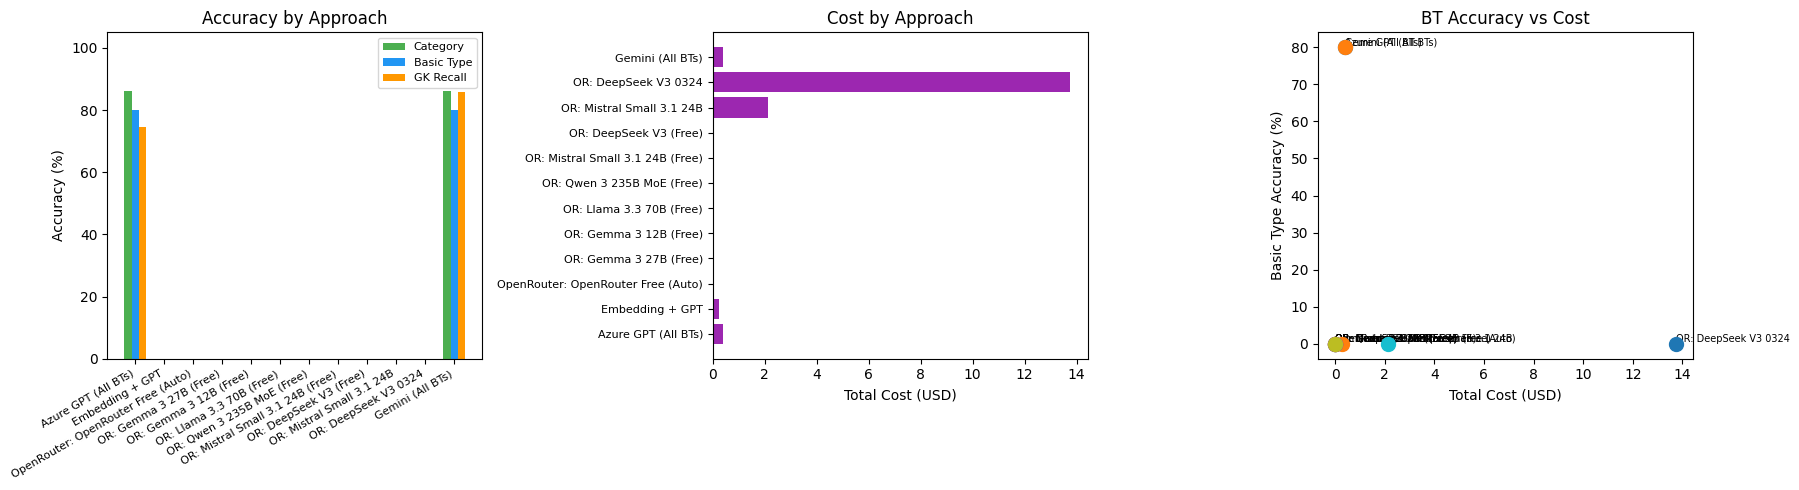

In [17]:
# =============================================================================
# CELL 11: Visualization — Accuracy vs Cost Charts
# =============================================================================
import matplotlib.pyplot as plt

if len(summary_df) > 0 and summary_df["Cat Acc (%)"].apply(lambda x: isinstance(x, (int, float))).any():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Filter to approaches that have numeric accuracy
    plot_df = summary_df[summary_df["Cat Acc (%)"].apply(lambda x: isinstance(x, (int, float)))].copy()

    # --- Chart 1: Accuracy comparison bar chart ---
    ax1 = axes[0]
    x = range(len(plot_df))
    w = 0.25
    ax1.bar([i - w for i in x], plot_df["Cat Acc (%)"], width=w, label="Category", color="#4CAF50")
    ax1.bar(x, plot_df["BT Acc (%)"], width=w, label="Basic Type", color="#2196F3")
    ax1.bar([i + w for i in x], plot_df["GK Recall (%)"], width=w, label="GK Recall", color="#FF9800")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(plot_df["Approach"], rotation=30, ha="right", fontsize=8)
    ax1.set_ylabel("Accuracy (%)")
    ax1.set_title("Accuracy by Approach")
    ax1.legend(fontsize=8)
    ax1.set_ylim(0, 105)

    # --- Chart 2: Cost comparison ---
    ax2 = axes[1]
    ax2.barh(plot_df["Approach"], plot_df["Total $"], color="#9C27B0")
    ax2.set_xlabel("Total Cost (USD)")
    ax2.set_title("Cost by Approach")
    ax2.tick_params(axis="y", labelsize=8)

    # --- Chart 3: Scatter — BT Accuracy vs Cost ---
    ax3 = axes[2]
    for _, row in plot_df.iterrows():
        ax3.scatter(row["Total $"], row["BT Acc (%)"], s=100, zorder=5)
        ax3.annotate(row["Approach"], (row["Total $"], row["BT Acc (%)"]),
                     fontsize=7, ha="left", va="bottom")
    ax3.set_xlabel("Total Cost (USD)")
    ax3.set_ylabel("Basic Type Accuracy (%)")
    ax3.set_title("BT Accuracy vs Cost")

    plt.tight_layout()
    plt.show()
else:
    print("No numeric results to plot yet.")

In [18]:
# =============================================================================
# CELL 12: Export Detailed Results per Approach (with ground truth + pass/fail/blank)
# =============================================================================
# For each approach, builds a detailed DataFrame merging ground truth with
# predictions, showing PASS/FAIL/BLANK for Category & BT, and Missing/Extra GKs.
# Saves to benchmark_predictions/ and displays inline.

export_dir = os.path.join(TESTING_DATA_DIR, "benchmark_predictions")
os.makedirs(export_dir, exist_ok=True)

for key, ar in all_results.items():
    if not ar.predictions:
        continue

    ev = evaluation_results.get(key)
    if not ev:
        continue

    # Build detailed DataFrame from per_sku evaluation data
    detail_rows = []
    for sku_ev in ev["per_sku"]:
        detail_rows.append({
            "SKU Name": sku_ev["SKU"],
            # --- Category ---
            "Expected Category": sku_ev["Expected Cat"],
            "Predicted Category": sku_ev["Predicted Cat"],
            "Category Result": sku_ev["Cat Status"],
            # --- Basic Type ---
            "Expected Basic Type": sku_ev["Expected BT"],
            "Predicted Basic Type": sku_ev["Predicted BT"],
            "BT Result": sku_ev["BT Status"],
            # --- Generic Keywords ---
            "GK Recall (%)": sku_ev["GK Recall (%)"],
            "Missing GKs": ", ".join(sku_ev["Missing GKs"]) if sku_ev["Missing GKs"] else "",
            "Extra GKs": ", ".join(sku_ev["Extra GKs"]) if sku_ev["Extra GKs"] else "",
        })

    detail_df = pd.DataFrame(detail_rows)

    # --- Print inline summary + table ---
    _ev_summary = evaluation_results[key]
    print(f"\n{'='*80}")
    print(f"📊 {ar.approach_name}  |  Cat: {_ev_summary['category_accuracy']}%  |  BT: {_ev_summary['basic_type_accuracy']}%  |  GK: {_ev_summary['avg_gk_recall']}%")
    print(f"{'='*80}")

    # Show pass/fail/blank counts
    cat_pass = detail_df["Category Result"].str.contains("PASS").sum()
    cat_blank = detail_df["Category Result"].str.contains("BLANK").sum()
    bt_pass = detail_df["BT Result"].str.contains("PASS").sum()
    bt_blank = detail_df["BT Result"].str.contains("BLANK").sum()
    total = len(detail_df)
    print(f"  Category: {cat_pass}/{total} passed, {cat_blank} blank  |  Basic Type: {bt_pass}/{total} passed, {bt_blank} blank")
    if _ev_summary.get('blank_count', 0) > 0:
        print(f"  BT accuracy (excl blanks): {_ev_summary['bt_acc_excl_blank']}%")

    # Display with pandas styling for readability
    with pd.option_context('display.max_colwidth', 60, 'display.max_rows', None, 'display.width', None):
        display(detail_df)

    # --- Save to CSV ---
    fname = f"{key}_predictions.csv"
    detail_df.to_csv(os.path.join(export_dir, fname), index=False, encoding="utf-8")
    print(f"  💾 Saved: {fname} ({len(detail_df)} rows)")

print(f"\n✅ All detailed predictions exported to {export_dir}")


📊 Azure GPT (All BTs)  |  Cat: 86.0%  |  BT: 80.0%  |  GK: 74.68%
  Category: 43/50 passed, 0 blank  |  Basic Type: 40/50 passed, 0 blank


,SKU Name,Expected Category,Predicted Category,Category Result,Expected Basic Type,Predicted Basic Type,BT Result,GK Recall (%),Missing GKs,Extra GKs
0,Kelloggs Corn Flakes 250g,Groceries,Groceries,✅ PASS,Corn Flakes,Corn Flakes,✅ PASS,80.0,Kelloggs Original Corn Flakes,
1,Md Original Green Chilli Sauce 400g,Groceries,Groceries,✅ PASS,Chilli Sauce,Chilli Sauce,✅ PASS,100.0,,"Hot Sauce, MD Chilli Sauce"
2,Bonita Elegant Beauty Soap (Rose)-65g,Personal Care,Household,❌ FAIL,Soap,Soap,✅ PASS,66.7,"Bonita Beauty Elegant Soap, Bonita Soap",Household
3,Pork Bacon Ends 300g,Poultry and Meat,Frozen Foods,❌ FAIL,Pork,Bacon,❌ FAIL,0.0,"Pork Bacon, Pork, Pork Bacon Ends, Bacon Ends, Poultry a...","Bacon, Frozen Foods"
4,Finagle Garlic Prawn Chiken Pizza 310g,Frozen Foods,Frozen Foods,✅ PASS,Pizza,Pizza,✅ PASS,100.0,,
5,La Treats Tea Time Cookies Sugar Free 100g,Groceries,Groceries,✅ PASS,Cookies,Cookies,✅ PASS,85.7,Biscuit,
6,Diva Lemon Fresh Detergent Soap 120g,Household,Household,✅ PASS,Detergent Soap,Detergent Soap,✅ PASS,100.0,,
7,Marvel Baby Diapers (L) 4pcs,Baby Care,Baby Care,✅ PASS,Baby Diapers,Baby Diapers,✅ PASS,100.0,,Marvel Large Baby Diapers
8,Eno Fruit Salt Orange Flavour Antacid Powder 5*5g,Pharmacy,Pharmacy,✅ PASS,Eno,Eno,✅ PASS,100.0,,
9,Ritzbury Revello Chocolate Hazelnut 100g,Groceries,Groceries,✅ PASS,Chocolate,Chocolate Bar,❌ FAIL,14.3,"Chocolate, Hazelnut Chocolate, Milk Chocolate, Revello C...",Chocolate Bar


  💾 Saved: azure_gpt_all_bts_predictions.csv (50 rows)

📊 Embedding + GPT  |  Cat: 0.0%  |  BT: 0.0%  |  GK: 0.0%
  Category: 0/50 passed, 50 blank  |  Basic Type: 0/50 passed, 50 blank
  BT accuracy (excl blanks): 0%


,SKU Name,Expected Category,Predicted Category,Category Result,Expected Basic Type,Predicted Basic Type,BT Result,GK Recall (%),Missing GKs,Extra GKs
0,Kelloggs Corn Flakes 250g,Groceries,,⬜ BLANK,Corn Flakes,,⬜ BLANK,0.0,"Kelloggs Corn Flakes, Kelloggs Original Corn Flakes, Cer...",
1,Md Original Green Chilli Sauce 400g,Groceries,,⬜ BLANK,Chilli Sauce,,⬜ BLANK,0.0,"Green Chilli Sauce, MD Green Chilli Sauce, Chilli Sauce,...",
2,Bonita Elegant Beauty Soap (Rose)-65g,Personal Care,,⬜ BLANK,Soap,,⬜ BLANK,0.0,"Bonita Beauty Elegant Soap, Personal Care, Bonita Soap, ...",
3,Pork Bacon Ends 300g,Poultry and Meat,,⬜ BLANK,Pork,,⬜ BLANK,0.0,"Pork Bacon, Bacon Ends, Poultry and Meat, Pork, Pork Bac...",
4,Finagle Garlic Prawn Chiken Pizza 310g,Frozen Foods,,⬜ BLANK,Pizza,,⬜ BLANK,0.0,"Pizza, Finagle Garlic Prawn Chicken Pizza, Frozen Foods,...",
5,La Treats Tea Time Cookies Sugar Free 100g,Groceries,,⬜ BLANK,Cookies,,⬜ BLANK,0.0,"Groceries, La Treats Tea Time Sugar Free Cookies, La Tre...",
6,Diva Lemon Fresh Detergent Soap 120g,Household,,⬜ BLANK,Detergent Soap,,⬜ BLANK,0.0,"Detergent, Household, Detergent Soap, Diva Detergent Soap",
7,Marvel Baby Diapers (L) 4pcs,Baby Care,,⬜ BLANK,Baby Diapers,,⬜ BLANK,0.0,"Large Baby Diapers, Baby Diapers, Baby Care, Marvel Baby...",
8,Eno Fruit Salt Orange Flavour Antacid Powder 5*5g,Pharmacy,,⬜ BLANK,Eno,,⬜ BLANK,0.0,"Eno, Antacid Powder, Eno Orange, Eno Orange Flavour Anta...",
9,Ritzbury Revello Chocolate Hazelnut 100g,Groceries,,⬜ BLANK,Chocolate,,⬜ BLANK,0.0,"Chocolate, Revello Chocolate, Hazelnut Chocolate, Ritzbu...",


  💾 Saved: embedding_plus_gpt_predictions.csv (50 rows)

📊 OpenRouter: OpenRouter Free (Auto)  |  Cat: 0.0%  |  BT: 0.0%  |  GK: 0.0%
  Category: 0/50 passed, 50 blank  |  Basic Type: 0/50 passed, 50 blank
  BT accuracy (excl blanks): 0%


...

  💾 Saved: openrouter_mistralai_mistral-small-3.1-24b-instruct_predictions.csv (50 rows)

📊 OR: DeepSeek V3 0324  |  Cat: 0.0%  |  BT: 0.0%  |  GK: 0.0%
  Category: 0/50 passed, 50 blank  |  Basic Type: 0/50 passed, 50 blank
  BT accuracy (excl blanks): 0%


,SKU Name,Expected Category,Predicted Category,Category Result,Expected Basic Type,Predicted Basic Type,BT Result,GK Recall (%),Missing GKs,Extra GKs
0,Kelloggs Corn Flakes 250g,Groceries,,⬜ BLANK,Corn Flakes,,⬜ BLANK,0.0,"Kelloggs Corn Flakes, Kelloggs Original Corn Flakes, Cer...",
1,Md Original Green Chilli Sauce 400g,Groceries,,⬜ BLANK,Chilli Sauce,,⬜ BLANK,0.0,"Green Chilli Sauce, MD Green Chilli Sauce, Chilli Sauce,...",
2,Bonita Elegant Beauty Soap (Rose)-65g,Personal Care,,⬜ BLANK,Soap,,⬜ BLANK,0.0,"Bonita Beauty Elegant Soap, Personal Care, Bonita Soap, ...",
3,Pork Bacon Ends 300g,Poultry and Meat,,⬜ BLANK,Pork,,⬜ BLANK,0.0,"Pork Bacon, Bacon Ends, Poultry and Meat, Pork, Pork Bac...",
4,Finagle Garlic Prawn Chiken Pizza 310g,Frozen Foods,,⬜ BLANK,Pizza,,⬜ BLANK,0.0,"Pizza, Finagle Garlic Prawn Chicken Pizza, Frozen Foods,...",
5,La Treats Tea Time Cookies Sugar Free 100g,Groceries,,⬜ BLANK,Cookies,,⬜ BLANK,0.0,"Groceries, La Treats Tea Time Sugar Free Cookies, La Tre...",
6,Diva Lemon Fresh Detergent Soap 120g,Household,,⬜ BLANK,Detergent Soap,,⬜ BLANK,0.0,"Detergent, Household, Detergent Soap, Diva Detergent Soap",
7,Marvel Baby Diapers (L) 4pcs,Baby Care,,⬜ BLANK,Baby Diapers,,⬜ BLANK,0.0,"Large Baby Diapers, Baby Diapers, Baby Care, Marvel Baby...",
8,Eno Fruit Salt Orange Flavour Antacid Powder 5*5g,Pharmacy,,⬜ BLANK,Eno,,⬜ BLANK,0.0,"Eno, Antacid Powder, Eno Orange, Eno Orange Flavour Anta...",
9,Ritzbury Revello Chocolate Hazelnut 100g,Groceries,,⬜ BLANK,Chocolate,,⬜ BLANK,0.0,"Chocolate, Revello Chocolate, Hazelnut Chocolate, Ritzbu...",


  💾 Saved: openrouter_deepseek_deepseek-chat-v3-0324_predictions.csv (50 rows)

📊 Gemini (All BTs)  |  Cat: 86.0%  |  BT: 80.0%  |  GK: 85.7%
  Category: 43/50 passed, 0 blank  |  Basic Type: 40/50 passed, 0 blank


,SKU Name,Expected Category,Predicted Category,Category Result,Expected Basic Type,Predicted Basic Type,BT Result,GK Recall (%),Missing GKs,Extra GKs
0,Kelloggs Corn Flakes 250g,Groceries,Groceries,✅ PASS,Corn Flakes,Corn Flakes,✅ PASS,100.0,,
1,Md Original Green Chilli Sauce 400g,Groceries,Groceries,✅ PASS,Chilli Sauce,Chilli Sauce,✅ PASS,100.0,,"Hot Sauce, MD Chilli Sauce"
2,Bonita Elegant Beauty Soap (Rose)-65g,Personal Care,Personal Care,✅ PASS,Soap,Soap,✅ PASS,100.0,,
3,Pork Bacon Ends 300g,Poultry and Meat,Frozen Foods,❌ FAIL,Pork,Bacon,❌ FAIL,0.0,"Pork Bacon, Pork, Pork Bacon Ends, Bacon Ends, Poultry a...","Bacon, Frozen Foods"
4,Finagle Garlic Prawn Chiken Pizza 310g,Frozen Foods,Frozen Foods,✅ PASS,Pizza,Pizza,✅ PASS,100.0,,
5,La Treats Tea Time Cookies Sugar Free 100g,Groceries,Groceries,✅ PASS,Cookies,Cookies,✅ PASS,100.0,,
6,Diva Lemon Fresh Detergent Soap 120g,Household,Household,✅ PASS,Detergent Soap,Detergent Soap,✅ PASS,100.0,,Laundry Soap
7,Marvel Baby Diapers (L) 4pcs,Baby Care,Baby Care,✅ PASS,Baby Diapers,Baby Diapers,✅ PASS,100.0,,Marvel Large Baby Diapers
8,Eno Fruit Salt Orange Flavour Antacid Powder 5*5g,Pharmacy,Pharmacy,✅ PASS,Eno,Eno,✅ PASS,100.0,,
9,Ritzbury Revello Chocolate Hazelnut 100g,Groceries,Groceries,✅ PASS,Chocolate,Chocolate Bar,❌ FAIL,14.3,"Chocolate, Hazelnut Chocolate, Milk Chocolate, Revello C...",Chocolate Bar


  💾 Saved: gemini_all_bts_predictions.csv (50 rows)

✅ All detailed predictions exported to c:\Code\AI Tagging\streamlit_app\Testing Data\benchmark_predictions
